In [109]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.image as mpimg
from pathlib import Path
import os
import glob
from PIL import Image
from IPython.display import display
from IPython.display import Image as dis_image 
from descartes import PolygonPatch
import alphashape
from shapely.geometry import Point, Polygon
import random
import math
from IPython.display import clear_output
import spacy
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score)


In [3]:
# Load data
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

def read_interest_area(trial_name): #edit for L and R cases
    boundary = []
    subject = ['',[],[]]
    with open("./data_here/interest areas/"+trial_name, "r") as file:
        
        content = file.read()
        bounds = content.split('\n')
        for i in range(2):
            items = bounds[i].split()
            subject[0] = items[-1]
            
            x_coords = []
            y_coords = []
            for coord in items[2:-1]:
                x, y = map(int, coord.split(','))
                x_coords.append(x)
                y_coords.append(y)
                
            subject[1] = x_coords
            subject[2] = y_coords
            boundary.append(subject)
            subject = ['',[],[]]

    return boundary

In [4]:
def get_file_names():

    folder_path = Path("./data_here/interest areas")
    file_names = [file.name for file in folder_path.iterdir() if file.is_file()]

    return file_names

In [5]:
def is_point_in_shape(x1, y1, x2, y2, coord):
    bound1 = list(zip(x1, y1))
    bound2 = list(zip(x2, y2))

    alpha_shape1 = Polygon(bound1)
    alpha_shape2 = Polygon(bound2)
    
    # Debug: Print Polygon Coordinates
    #print(f"Polygon Coordinates: {list(alpha_shape1.exterior.coords)}")
    #print(f"Polygon Coordinates: {list(alpha_shape2.exterior.coords)}")

    point = Point(coord[0], coord[1])

    if alpha_shape1.contains(point):
        area = "bound1"
    elif alpha_shape2.contains(point):
        area = "bound2"
    else:
        area = "empty"

    return area

In [6]:
def plot_trial(x_plots, y_plots, trial_name, num_frames=20, save_folder="plot_images"):
    folder_path = "./plot_images"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs(save_folder, exist_ok=True)
    
    # Filter out None values
    valid_indices = ~np.isnan(x_plots) & ~np.isnan(y_plots)
    x_plots = np.array(x_plots)[valid_indices]
    y_plots = np.array(y_plots)[valid_indices]

    boundary = read_interest_area(trial_name)
    x_bound1 = boundary[0][1]
    x_bound1.append(x_bound1[0])
    y_bound1 = boundary[0][2]
    y_bound1.append(y_bound1[0])
    x_bound2 = boundary[1][1]
    x_bound2.append(x_bound2[0])
    y_bound2 = boundary[1][2]
    y_bound2.append(y_bound2[0])

    # Generate 30 evenly spaced indices
    indices = np.linspace(0, len(x_plots) - 1, num_frames, dtype=int)
    img = mpimg.imread('./data_here/target images/target_girl_taking_cake2_R.bmp')
    height, width, _ = img.shape

    half_width = width / 2
    half_height = height / 2
    xmin = 511 - half_width
    xmax = 511 + half_width
    ymin = 383 - half_height
    ymax = 383 + half_height

    for i in indices:
        plt.figure(figsize=(6, 6))
        #plt.xlim(0, 1000)
        #plt.ylim(0, 1000)
        
        plt.imshow(img, extent=[xmin, xmax, ymax, ymin], aspect='auto', alpha = 0.3)
        
        plt.plot(x_plots[:i+1], y_plots[:i+1], marker='o', linestyle='-', color='blue', zorder = 3)
        plt.plot(x_bound1, y_bound1, marker='o', linestyle='-', color='red')
        plt.plot(x_bound2, y_bound2, marker='o', linestyle='-', color='green')
        section = is_point_in_shape(x_bound1, y_bound1, x_bound2, y_bound2, [x_plots[i], y_plots[i]])
        if section == "bound1":
            plt.scatter(x_plots[i], y_plots[i], c='red', zorder=4)
        elif section == "bound2":
            plt.scatter(x_plots[i], y_plots[i], c='green', zorder=4)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Trial')
        #plt.gca().invert_yaxis()
        plot_filename = os.path.join(save_folder, f"{str(i)}.png")
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.close()

def get_trial_coords(subitem):
    filtered_df = results_df[results_df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_trial_name(item):
    picture_name = results_df[results_df['item'] == int(item)]
    pic_name_split = picture_name['picture_name'].unique()[0][:-7].split("_")
    subject1 = pic_name_split[0]
    subject2 = pic_name_split[-1]

    file_names = get_file_names()
    for file in file_names:
        split_file = file.split("_")
        if subject1 in split_file and subject2 in split_file: # This doesn't work, items 3 7 10 17 etc does not have the same subject names
            # Might be able to use agent and patient for this with a bit of editing
            return file

    return None

def show_trial_plot(subitem, frames=20):
    x_coord, y_coord = get_trial_coords(subitem)
    plot_trial(x_coord, y_coord, get_trial_name(subitem[7:]), frames)  
    display_plot_gif()
    display(dis_image(filename="saved_gifs/animated_GMM.gif"))

In [7]:
def display_plot_gif():
    os.makedirs("saved_gifs", exist_ok=True)
    folder_path = "./saved_gifs"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
            
    files = glob.glob(r"plot_images/*.png")
    files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))  # Sort numerically
    
    image_array = []
    progress = 0

    for my_file in files:
        progress += 1
    
        image = Image.open(my_file)
        image_array.append(image)
        #print(progress)

    #print('image_arrays shape:', np.array(image_array).shape())
    #print(type(image_array[2]))
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    plt.axis('off')

    def update(i):
        im.set_array(image_array[i])
        #print(i)
        return im,

    # Create the animation object
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=200, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    animation_fig.save("./saved_gifs/animated_GMM.gif")
    plt.close()

MovieWriter ffmpeg unavailable; using Pillow instead.


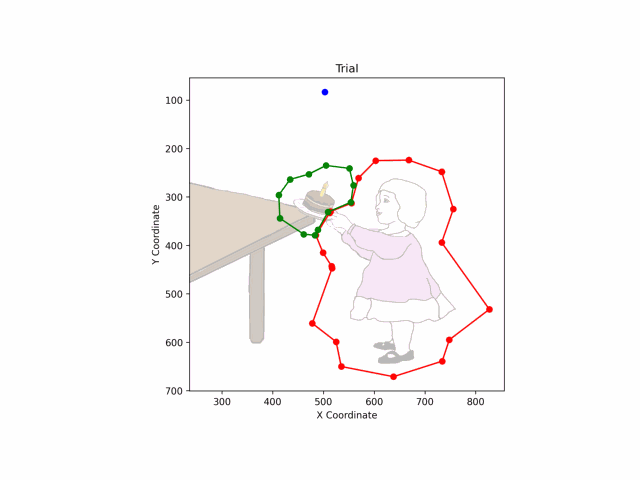

In [213]:
show_trial_plot('sub119_6', 50)
#get_trial_name('25')

In [106]:
#print(results_df['picture_name'].unique())
print(results_df.loc[results_df['item'] == 44, 'picture_name'].unique())


['tiger_scratching_tourist_active']


In [201]:
results_df

,item,subitem,counter,sub,IntAr,X_coord,Y_coord,Time,participant_language,input,...,the1_offset,agent,agent_onset,agent_offset,the2,the2_onset,the2_offset,patient,patient_onset,patient_offset
0,1,sub101_1,1,sub101,empty,484.3,131,10,L1_participant,L1_input,...,547,stork,547,995,the,1629,1734,baby,1734,2182
1,1,sub101_1,2,sub101,empty,484.3,131,20,L1_participant,L1_input,...,547,stork,547,995,the,1629,1734,baby,1734,2182
2,1,sub101_1,3,sub101,empty,484.3,131,30,L1_participant,L1_input,...,547,stork,547,995,the,1629,1734,baby,1734,2182
3,1,sub101_1,4,sub101,empty,empty,empty,40,L1_participant,L1_input,...,547,stork,547,995,the,1629,1734,baby,1734,2182
4,1,sub101_1,5,sub101,empty,empty,empty,50,L1_participant,L1_input,...,547,stork,547,995,the,1629,1734,baby,1734,2182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735995,22,sub201_22,1890796,sub201,patient,623.8,349.4,3960,BILINGUAL,L2_input,...,615,woman,615,950,the,1516,1677,present,1677,2272
1735996,22,sub201_22,1890797,sub201,patient,623.8,349.4,3970,BILINGUAL,L2_input,...,615,woman,615,950,the,1516,1677,present,1677,2272
1735997,22,sub201_22,1890798,sub201,patient,623.8,349.4,3980,BILINGUAL,L2_input,...,615,woman,615,950,the,1516,1677,present,1677,2272
1735998,22,sub201_22,1890799,sub201,patient,623.8,349.4,3990,BILINGUAL,L2_input,...,615,woman,615,950,the,1516,1677,present,1677,2272


In [9]:
print(list(results_df))


['item', 'subitem', 'counter', 'sub', 'IntAr', 'X_coord', 'Y_coord', 'Time', 'participant_language', 'input', 'trial_number', 'condition', 'memory_binary_response', 'RT', 'memory_accuracy', 'picture_name', 'the1', 'the1_onset', 'the1_offset', 'agent', 'agent_onset', 'agent_offset', 'the2', 'the2_onset', 'the2_offset', 'patient', 'patient_onset', 'patient_offset']


In [ ]:
def create_mapping_file(): # TODO: check about 3 missing boundary files 
    

In [115]:
def get_subitem_data(subitem):
    x_coords, y_coords = get_trial_coords(subitem)
    filtered_df = results_df[results_df['subitem'] == subitem]
    last_area = 'empty'
    area_order = 0
    gaze_shift = 0
    distractions = -1
    distracted = False
    a_dists = []
    b_dists = []
    a_centroid, b_centroid = get_activity_centroids(filtered_df['item'].unique()[0])
    agent_react_time = None
    patient_react_time = None
    agent_leave_time = None
    patient_leave_time = None
    agent_anti_altered = False
    patient_anti_altered = False
    anticipated_agent_onset = False
    anticipated_patient_onset = False

    agent_onset = filtered_df['agent_onset'].unique()[0]
    agent_offset = filtered_df['agent_offset'].unique()[0]
    patient_onset = filtered_df['patient_onset'].unique()[0]
    patient_offset = filtered_df['patient_offset'].unique()[0]
    
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if last_area == 'agent' and current_area == 'patient':
            area_order = int(1)
            break
        elif last_area == 'patient' and current_area == 'agent':
            area_order = int(2)
            break
        elif current_area != 'empty':
            last_area = current_area

    last_area = 'empty'
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if row['X_coord'] == 'empty':
            continue
        elif last_area != current_area:
            gaze_shift += 1 # gaze shift includes all area changes except nan values
            last_area = current_area
            distracted = False
        elif last_area == 'empty' and current_area == 'empty' and not distracted:
            distractions += 1
            distracted = True
        if current_area == 'agent' and row['Time'] >= agent_onset and agent_react_time == None:
            agent_react_time = float(row['Time'] - agent_onset)
        if current_area == 'patient' and row['Time'] >= patient_onset and patient_react_time == None:
            patient_react_time = float(row['Time'] - patient_onset)
        if current_area != 'agent' and agent_react_time != None and agent_leave_time == None:
            agent_leave_time = float(row['Time'] - agent_onset)
        if current_area != 'patient' and patient_react_time != None and patient_leave_time == None:
            patient_leave_time = float(row['Time'] - patient_onset)
        if row['Time'] >= agent_onset and not agent_anti_altered:
            if current_area == 'agent':
                anticipated_agent_onset = True
            elif current_area != 'agent':
                anticipated_agent_onset = False
            agent_anti_altered = True
        if row['Time'] >= patient_onset and not patient_anti_altered:
            if current_area == 'patient':
                anticipated_patient_onset = True
            elif current_area != 'agent':
                anticipated_patient_onset = False
            patient_anti_altered = True
            

    #print(agent_react_time)
    #print(agent_leave_time)

    agent_df = filtered_df[(filtered_df['Time'] >= agent_onset) & (filtered_df['Time'] <= agent_offset)]
    patient_df = filtered_df[(filtered_df['Time'] >= patient_onset) & (filtered_df['Time'] <= patient_offset)]

    TA_strict_a = ((agent_df['IntAr'] == 'agent').sum()) / len(agent_df)
    TA_strict_b = ((patient_df['IntAr'] == 'patient').sum()) / len(patient_df)

    TA_loose_a = False if (agent_df['IntAr'] == 'agent').sum() == 0 else True
    TA_loose_b = False if (patient_df['IntAr'] == 'patient').sum() == 0 else True

    order = 1 if agent_onset < patient_onset else 2
    ordered = True if area_order == order else False

    for i in range(len(x_coords)):
        a_dists.append(math.dist((x_coords[i], y_coords[i]), a_centroid))
        b_dists.append(math.dist((x_coords[i], y_coords[i]), b_centroid)) 

    duration_agent = (filtered_df['IntAr'] == 'agent').sum() * 10
    duration_patient = (filtered_df['IntAr'] == 'patient').sum() * 10
    duration_empty = (filtered_df['IntAr'] == 'empty').sum() * 10

    similarity = get_semantic_relationship(subitem)

    test_accuracy = False if filtered_df['memory_accuracy'].unique()[0] == "incorrect_response" else True
        
    return x_coords, y_coords, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, similarity, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset

def get_activity_centroids(item):
    item_df = results_df[results_df['item'] == item]
    
    a_item_df = item_df[item_df['IntAr'] == 'agent']
    x_mean = pd.to_numeric(a_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['Y_coord'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['IntAr'] == 'patient']
    x_mean = pd.to_numeric(b_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['Y_coord'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid
    

def gen_training_dataframe():
    complete_df = pd.DataFrame(columns=['subitem', 'x_coords', 'y_coords', 'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 
                                        'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'ordered', 'a_dists', 'b_dists', 'duration_agent', 
                                        'duration_patient', 'duration_empty', 'semantic_relationship', 'test_accuracy', 'agent_react_time', 
                                        'patient_react_time', 'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 
                                        'patient_focus_on_onset'])
    #trial = "sub101_16" #12, 16, 17
    for trial in results_df['subitem'].unique():
        x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset = get_subitem_data(trial)
        complete_df.loc[len(complete_df)] = [trial, x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, 
                                             TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, 
                                             semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, 
                                             patient_leave_time, anticipated_agent_onset, anticipated_patient_onset]
        #print(complete_df.loc[len(complete_df)-1])
        print(trial)
        clear_output(wait=True)
    return complete_df

complete_df = gen_training_dataframe()
complete_df

,subitem,x_coords,y_coords,area_order,gaze_shift,distractions,TA_strict_a,TA_strict_b,TA_loose_a,TA_loose_b,...,duration_patient,duration_empty,semantic_relationship,test_accuracy,agent_react_time,patient_react_time,agent_leave_time,patient_leave_time,agent_focus_on_onset,patient_focus_on_onset
0,sub101_1,"[484.3, 484.3, 484.3, nan, nan, 516.4, 516.4, ...","[131.0, 131.0, 131.0, nan, nan, 75.6, 75.6, 75...",1,3,0,1.000000,0.000000,True,False,...,380,340,0.538630,False,3.0,556.0,1743.0,976.0,True,False
1,sub101_2,"[524.3, 524.3, 524.3, 524.3, 524.3, 524.3, 524...","[77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77....",2,4,0,0.000000,0.000000,False,False,...,2630,300,0.355066,True,860.0,707.0,1760.0,2157.0,False,False
2,sub101_3,"[533.9, 533.9, 533.9, 533.9, 533.9, 533.9, 533...","[105.2, 105.2, 105.2, 105.2, 105.2, 105.2, 105...",1,6,1,0.488372,0.862069,True,True,...,1050,770,0.195968,True,5.0,87.0,255.0,667.0,True,False
3,sub101_4,"[520.3, 520.3, 520.3, 520.3, 520.3, 520.3, 520...","[97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97....",2,8,0,1.000000,0.236364,True,True,...,990,880,0.657580,False,8.0,66.0,928.0,236.0,True,True
4,sub101_5,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",2,7,1,0.561644,0.388889,True,True,...,1620,1250,0.444074,False,324.0,7.0,804.0,327.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,sub201_18,"[508.5, 508.5, 508.5, 508.5, 508.5, 508.5, 508...","[99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99....",1,5,0,0.554217,1.000000,True,True,...,2370,830,0.788806,False,212.0,8.0,732.0,1448.0,False,True
4336,sub201_19,"[514.9, 514.9, 514.9, 514.9, 514.9, 514.9, 514...","[103.6, 103.6, 103.6, 103.6, 103.6, 103.6, 103...",0,1,0,0.000000,1.000000,False,True,...,3630,370,0.471298,True,NaN,5.0,NaN,NaN,False,True
4337,sub201_20,"[508.0, 508.0, 508.0, 508.0, 508.0, 508.0, 508...","[101.5, 101.5, 101.5, 101.5, 101.5, 101.5, 101...",1,5,0,0.084746,0.375000,True,True,...,540,970,0.618740,True,1.0,9.0,111.0,399.0,True,True
4338,sub201_21,"[512.7, 512.7, 512.7, 512.7, 512.7, 512.7, 512...","[106.7, 106.7, 106.7, 106.7, 106.7, 106.7, 106...",1,3,0,0.000000,1.000000,False,True,...,2900,360,0.685809,False,2881.0,7.0,NaN,1497.0,False,True


In [8]:
def get_semantic_relationship(trial):
    nlp = spacy.load('en_core_web_sm')
    df = results_df[results_df['subitem'] == trial]
    agent = nlp(df['agent'].unique()[0])
    patient = nlp(df['patient'].unique()[0])

    similarity = agent.similarity(patient)
    return similarity

In [13]:
file_path = './data_here/sample reports/sub_sample_reports_L1_input.txt'

with open(file_path, 'r') as file:
    lines = [next(file) for _ in range(4)]
    
for line in lines:
    print(line.strip())


df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated values, reading only the first 10 lines

print(df["EYE_TRACKED"].unique())

RECORDING_SESSION_LABEL	DATA_FILE	EYE_TRACKED	TRIAL_INDEX	TRIAL_LABEL	TRIAL_START_TIME	item_type	cond	list	pic	order_at_study	sentence	AVERAGE_GAZE_X	AVERAGE_GAZE_Y	AVERAGE_INTEREST_AREAS	AVERAGE_INTEREST_AREA_ID	AVERAGE_INTEREST_AREA_LABEL	SAMPLE_INDEX	TIMESTAMP
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	646.20	413.10	[]	.	.	1	1257589.00
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	645.40	412.60	[]	.	.	2	1257590.00
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	644.80	412.10	[]	.	.	3	1257591.00


/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_74652/2831557348.py:10: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated values, reading only the first 10 lines


['Left' 'Right']


In [77]:
print(len(df["RECORDING_SESSION_LABEL"].unique()))

51


In [76]:
print(len(df["SAMPLE_INDEX"]))

30569229


In [20]:
file_path = './data_here/sample reports/sub_sample_reports_L2_input.txt'
df2 = pd.read_csv(file_path, sep='\t')

/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_74652/1930825315.py:2: DtypeWarning: Columns (12,13,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(file_path, sep='\t')


In [50]:
print(df2["list"].unique())

['list12_L2' 'list34_L2']


In [66]:
with open(file_path, 'r') as file:
    lines = [next(file) for _ in range(10000)]
    
for line in lines:
    print(line.strip())

RECORDING_SESSION_LABEL	DATA_FILE	EYE_TRACKED	TRIAL_INDEX	TRIAL_LABEL	TRIAL_START_TIME	item_type	cond	list	pic	order_at_study	sentence	AVERAGE_GAZE_X	AVERAGE_GAZE_Y	AVERAGE_INTEREST_AREAS	AVERAGE_INTEREST_AREA_ID	AVERAGE_INTEREST_AREA_LABEL	AVERAGE_PUPIL_SIZE	SAMPLE_INDEX	TIMESTAMP
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.50	107.80	[]	.	.	851.00	1	1662976.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.40	107.70	[]	.	.	851.00	2	1662977.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.40	107.90	[]	.	.	852.00	3	1662978.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.30	108.00	[]	.	.	852.00	4	1662979.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie ca

In [64]:
print(results_df["trial_number"].unique())

[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 42 10 21 22 43 44 41]


In [160]:
from sklearn.preprocessing import StandardScaler

# defining the dependent and independent variables 
X = complete_df[['gaze_shift', 'distractions', 'TA_strict_a', 'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'ordered', 
                 'duration_agent', 'duration_empty', 'semantic_relationship', 'agent_react_time', 'patient_react_time', 
                 'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 'patient_focus_on_onset']] 
y = complete_df[['test_accuracy']].astype(float)

X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0) 
bool_cols = ['TA_loose_a', 'TA_loose_b', 'ordered', 'agent_focus_on_onset', 'patient_focus_on_onset']
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]

print(vif_data)

# building the model and fitting the data 
#log_reg = sm.Logit(y_train, X_train_scaled, weights=np.where(y_train == 1, 1, y_train.value_counts()[1] / y_train.value_counts()[0])).fit()

log_reg = sm.Logit(y_train, X_train_scaled).fit()
print(log_reg.summary())

yhat = log_reg.predict(X_test_scaled) 
prediction = list(map(round, yhat)) 
  
# comparing original and predicted values of y 
print('Actual values', list(y_test.values)) 
print('Predictions :', prediction) 

cm = confusion_matrix(y_test, prediction)  
print ("Confusion Matrix : \n", cm)  
  
# accuracy score of the model 
print('Test accuracy = ', accuracy_score(y_test, prediction))

                   Feature        VIF
0               gaze_shift  12.763837
1             distractions   1.734980
2              TA_strict_a   6.183379
3              TA_strict_b   9.033447
4               TA_loose_a   9.308307
5               TA_loose_b  12.639727
6                  ordered   2.911646
7           duration_agent   9.825680
8           duration_empty   5.914459
9    semantic_relationship  11.950018
10        agent_react_time   4.008945
11      patient_react_time   3.553809
12        agent_leave_time   5.350653
13      patient_leave_time   3.231355
14    agent_focus_on_onset   3.778618
15  patient_focus_on_onset   5.773473
Optimization terminated successfully.
         Current function value: 0.691056
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          test_accuracy   No. Observations:                 3472
Model:                          Logit   Df Residuals:                     3456
Method:        

test_accuracy
1.0              2490
0.0               982
Name: count, dtype: int64
